<a href="https://colab.research.google.com/github/S-ad-ops/ML-Projects/blob/main/DT_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.tree import plot_tree

In [6]:
iris =load_iris()
X = iris.data
y = iris.target

In [7]:
print(iris.feature_names)
print(iris.target_names)
print(X.shape)
print(y.shape)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
(150, 4)
(150,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3, #prevents overfitting
    random_state=42,
)

In [10]:
model.fit(
    X_train,
    y_train,
)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [11]:
y_pred = model.predict(X_test)

In [13]:
accuracy = accuracy_score(
    y_test,
    y_pred,
)
print(accuracy)

1.0


In [14]:
print(
    confusion_matrix(
        y_test,
        y_pred,
    )
)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [18]:
#performance report for each class
print(
    classification_report(
        y_test,
        y_pred,
        target_names= iris.target_names,
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [19]:
#which feature influenced the model most
print(model.feature_importances_)


[0.         0.         0.93462632 0.06537368]


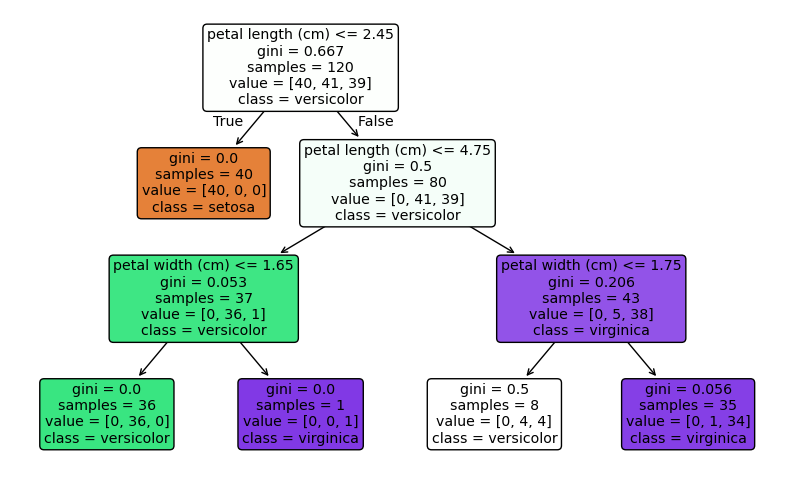

In [20]:
plt.figure(figsize=(10, 6))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
)
plt.show()